# 04 · Comparative Summary

This notebook synthesises results from notebooks 02 and 03 into a single cross-metric
comparison suitable for the thesis results chapter.

**Units:**
- Energy → **J** (Joules)
- Time → **ms** (milliseconds)
- EDP → **J·ms** (Joule-milliseconds)

**Outputs:**
- `outputs/ranking_summary.csv` — full multi-metric ranking table
- Radar chart per paradigm
- Normalised metrics heatmap
- Top 3 / Bottom 3 per metric
- Key findings bullet list

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from itertools import combinations
from pathlib import Path
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.dpi': 150, 'savefig.dpi': 150, 'figure.figsize': (12, 6)})

In [2]:
# ── Column names as they appear in results_clean_runs.csv ────────────────────
# Units already converted by notebooks/01_data_cleaning.ipynb
COL_CPU_ENERGY = 'cpu_energy_rapl_msr_component-package_0-j'
COL_MEM_ENERGY = 'memory_energy_rapl_msr_component-dram_0-j'
COL_TIME       = 'phase_time_syscall_system-system-ms'
COL_CPU_CARBON = 'cpu_carbon_rapl_msr_component-package_0-g'
COL_MEM_CARBON = 'memory_carbon_rapl_msr_component-dram_0-g'

ALPHA = 0.05

FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)
OUTPUTS_DIR = Path('outputs')
OUTPUTS_DIR.mkdir(exist_ok=True)

LANG_DISPLAY = {
    'c': 'C', 'cpp': 'C++', 'csharp': 'C#', 'fsharp': 'F#',
    'nodejs': 'JavaScript', 'dart': 'Dart', 'erlang': 'Erlang',
    'go': 'Go', 'haskell': 'Haskell', 'java': 'Java', 'lua': 'Lua',
    'ocaml': 'OCaml', 'perl': 'Perl', 'php': 'PHP',
    'python': 'Python', 'ruby': 'Ruby', 'rust': 'Rust', 'swift': 'Swift',
}

PARADIGM = {
    'C': 'AOT', 'C++': 'AOT', 'C#': 'AOT', 'Dart': 'AOT', 'Go': 'AOT',
    'Haskell': 'AOT', 'Java': 'AOT', 'OCaml': 'AOT', 'Rust': 'AOT', 'Swift': 'AOT',
    'Erlang': 'JIT', 'F#': 'JIT', 'JavaScript': 'JIT', 'PHP': 'JIT', 'Ruby': 'JIT',
    'Lua': 'Interpreted', 'Perl': 'Interpreted', 'Python': 'Interpreted',
}

PARADIGM_COLORS = {'AOT': '#2980b9', 'JIT': '#e67e22', 'Interpreted': '#27ae60'}
PARADIGM_ORDER  = ['AOT', 'JIT', 'Interpreted']

# Marker style for the mean (▲) overlaid on boxplots/violins (showmeans=True).
MEANPROPS = dict(marker='^', markerfacecolor='white', markeredgecolor='black', markersize=6)

# Data pre-cleaned by notebooks/01_data_cleaning.ipynb:
#   - Outliers removed per (language × benchmark) group, IQR fence on CPU energy + time
#   - Units already converted (J, ms, g, MB, W)
#
# Single source: results_clean_runs.csv — per-run rows.
#   df       = all per-run rows, used for distribution views and non-parametric tests.
#   df_mean  = per-(language × benchmark) mean, computed here from df.
#              Rankings, heatmaps and summary tables use df_mean via lang_means().
df = pd.read_csv('../../results/results_clean_runs.csv')
df['language'] = df['language'].replace(LANG_DISPLAY)
df['paradigm'] = df['language'].map(PARADIGM)

_id_cols = {'run_id', 'measured_at', 'language', 'benchmark', 'paradigm'}
_metric_cols = [c for c in df.columns if c not in _id_cols]
df_mean = df.groupby(['language', 'benchmark'])[_metric_cols].mean().reset_index()
df_mean['paradigm'] = df_mean['language'].map(PARADIGM)

# Energy-Delay Product from representative (mean) values per cell: lower is better.
# EDP = (CPU + Memory energy) × time, in J·ms.
df_mean['EDP'] = (df_mean[COL_CPU_ENERGY] + df_mean[COL_MEM_ENERGY]) * df_mean[COL_TIME]


def lang_means(cols):
    """Per-language two-step mean for column(s) `cols` (str or list): average the
    per-benchmark cell means with equal benchmark weight. Returns a Series for a
    single column or a DataFrame for a list. Derived from results_clean_runs.csv."""
    return df_mean.groupby('language')[cols].mean()


print(f"Runs shape: {df.shape} | Cell-means shape: {df_mean.shape}")
print(f"Languages ({df['language'].nunique()}): {sorted(df['language'].unique())}")
print(f"Benchmarks ({df['benchmark'].nunique()}): {sorted(df['benchmark'].unique())}")
print("Units: energy=J | time=ms | carbon=g | disk/net=MB | power=W")
print("Rankings use the two-step mean (equal benchmark weight) via lang_means(); "
      "boxplots/violins and non-parametric tests use the per-run df.")
df_mean.head(3)

Runs shape: (1280, 17) | Cell-means shape: (144, 16)
Languages (18): ['C', 'C#', 'C++', 'Dart', 'Erlang', 'F#', 'Go', 'Haskell', 'Java', 'JavaScript', 'Lua', 'OCaml', 'PHP', 'Perl', 'Python', 'Ruby', 'Rust', 'Swift']
Benchmarks (8): ['binary-trees', 'fannkuch-redux', 'fasta', 'k-nucleotide', 'mandelbrot', 'n-body', 'regex-redux', 'spectral-norm']
Units: energy=J | time=ms | carbon=g | disk/net=MB | power=W
Rankings use the two-step mean (equal benchmark weight) via lang_means(); boxplots/violins and non-parametric tests use the per-run df.


,language,benchmark,cpu_carbon_rapl_msr_component-package_0-g,cpu_energy_rapl_msr_component-package_0-j,disk_total_read_cgroup_container-container-mb,disk_total_write_cgroup_container-container-mb,embodied_carbon_share_machine-system-g,memory_carbon_rapl_msr_component-dram_0-g,memory_energy_rapl_msr_component-dram_0-j,network_carbon_formula_global-formula-g,network_energy_formula_global-formula-j,network_power_formula_global-formula-w,network_total_cgroup_container-container-mb,phase_time_syscall_system-system-ms,paradigm,EDP
0,C,binary-trees,0.002967,31.976886,0.192512,0.0,0.001753,0.000122,1.311170,0.000000e+00,0.000000,0.0,0.000000,1221.817400,AOT,40671.925300
1,C,fannkuch-redux,0.006453,69.556996,0.000000,0.0,0.003131,0.000063,0.682479,5.714286e-07,0.005702,0.0,0.000039,2182.097714,AOT,153269.397538
2,C,fasta,0.003574,38.523294,0.000000,0.0,0.002074,0.000081,0.870375,1.666667e-06,0.018067,0.0,0.000122,1445.462222,AOT,56942.061458


## 1. Multi-Metric Ranking Table

Each language is ranked (1 = best) on four metrics:
- Mean CPU Energy (J)
- Mean Memory Energy (J)
- Mean Execution Time (ms)
- Mean EDP — (CPU + Memory Energy) × Time (J·ms)

Values use benchmark-level means averaged across all 8 benchmarks (equal benchmark weight).
The overall rank is the average of the four individual ranks.

In [3]:
# Two-step mean (equal benchmark weight): df_mean already holds the per-cell mean
# energy/time and a per-cell EDP column, so we only average the 8 cells per language.
agg = df_mean.groupby('language').agg(
    paradigm     = ('paradigm', 'first'),
    cpu_mean_J   = (COL_CPU_ENERGY, 'mean'),
    mem_mean_J   = (COL_MEM_ENERGY, 'mean'),
    time_mean_ms = (COL_TIME, 'mean'),
    edp_mean_Jms = ('EDP', 'mean'),
).round(4)

agg['cpu_rank']  = agg['cpu_mean_J'].rank().astype(int)
agg['mem_rank']  = agg['mem_mean_J'].rank().astype(int)
agg['time_rank'] = agg['time_mean_ms'].rank().astype(int)
agg['edp_rank']  = agg['edp_mean_Jms'].rank().astype(int)
agg['overall_rank'] = (
    (agg['cpu_rank'] + agg['mem_rank'] + agg['time_rank'] + agg['edp_rank']) / 4
).round(2)

ranking = agg.sort_values('edp_rank')
ranking.index.name = 'Language'
ranking[['paradigm', 'cpu_mean_J', 'mem_mean_J', 'time_mean_ms', 'edp_mean_Jms',
         'cpu_rank', 'mem_rank', 'time_rank', 'edp_rank', 'overall_rank']]

,paradigm,cpu_mean_J,mem_mean_J,time_mean_ms,edp_mean_Jms,cpu_rank,mem_rank,time_rank,edp_rank,overall_rank
Language,,,,,,,,,,
C,AOT,54.0807,1.0891,2050.4797,1.598178e+05,2,1,2,1,1.50
C++,AOT,48.0054,1.2643,2019.4713,1.652646e+05,1,2,1,2,1.50
C#,AOT,66.3010,2.3637,2796.8219,2.739213e+05,3,4,3,3,3.25
Rust,AOT,81.4675,1.3812,3068.6467,4.616284e+05,4,3,4,4,3.75
F#,JIT,118.6830,3.3530,4193.8991,7.159762e+05,5,5,5,5,5.00
Java,AOT,133.6244,4.1960,5147.2035,9.708105e+05,6,7,6,6,6.25
OCaml,AOT,153.5501,3.5966,6440.3073,1.304707e+06,8,6,9,7,7.50
Go,AOT,152.5651,4.5301,6071.3053,1.348398e+06,7,8,8,8,7.75
JavaScript,JIT,164.2044,5.4909,7185.9161,1.764815e+06,9,10,10,9,9.50


In [4]:
export = ranking[['paradigm', 'cpu_mean_J', 'mem_mean_J', 'time_mean_ms',
                  'edp_mean_Jms', 'cpu_rank', 'mem_rank', 'time_rank',
                  'edp_rank', 'overall_rank']].copy()
export.columns = ['Paradigm', 'CPU Energy (J)', 'Mem Energy (J)', 'Time (ms)',
                  'EDP (J·ms)', 'CPU Rank', 'Mem Rank', 'Time Rank', 'EDP Rank',
                  'Overall Rank']
export.to_csv(OUTPUTS_DIR / 'ranking_summary.csv')
print(f"Saved → {OUTPUTS_DIR / 'ranking_summary.csv'}")
export

Saved → outputs/ranking_summary.csv


,Paradigm,CPU Energy (J),Mem Energy (J),Time (ms),EDP (J·ms),CPU Rank,Mem Rank,Time Rank,EDP Rank,Overall Rank
Language,,,,,,,,,,
C,AOT,54.0807,1.0891,2050.4797,1.598178e+05,2,1,2,1,1.50
C++,AOT,48.0054,1.2643,2019.4713,1.652646e+05,1,2,1,2,1.50
C#,AOT,66.3010,2.3637,2796.8219,2.739213e+05,3,4,3,3,3.25
Rust,AOT,81.4675,1.3812,3068.6467,4.616284e+05,4,3,4,4,3.75
F#,JIT,118.6830,3.3530,4193.8991,7.159762e+05,5,5,5,5,5.00
Java,AOT,133.6244,4.1960,5147.2035,9.708105e+05,6,7,6,6,6.25
OCaml,AOT,153.5501,3.5966,6440.3073,1.304707e+06,8,6,9,7,7.50
Go,AOT,152.5651,4.5301,6071.3053,1.348398e+06,7,8,8,8,7.75
JavaScript,JIT,164.2044,5.4909,7185.9161,1.764815e+06,9,10,10,9,9.50


## 2. Normalized Efficiency Comparison

Each metric is expressed as a **ratio relative to the best (lowest) language** — so 1.0 = best
and e.g. 5.0 means this language consumes 5× more CPU energy / RAM energy / time than the
most efficient language. Values are computed from the **mean** across all 8 benchmarks,
matching the CLBG presentation style.

In [5]:
# Two-step mean (equal benchmark weight) straight from the per-cell means in df_mean.
norm_agg = lang_means([COL_CPU_ENERGY, COL_MEM_ENERGY, COL_TIME])

norm_agg['CPU Energy Normalized'] = (norm_agg[COL_CPU_ENERGY] / norm_agg[COL_CPU_ENERGY].min()).round(2)
norm_agg['RAM Energy Normalized'] = (norm_agg[COL_MEM_ENERGY] / norm_agg[COL_MEM_ENERGY].min()).round(2)
norm_agg['Time Normalized']       = (norm_agg[COL_TIME]        / norm_agg[COL_TIME].min()).round(2)

norm_ranking = (
    norm_agg[['CPU Energy Normalized', 'RAM Energy Normalized', 'Time Normalized']]
    .sort_values('CPU Energy Normalized')
    .reset_index()
    .rename(columns={'language': 'Language'})
)

norm_ranking.index = norm_ranking.index + 1  # rank starts at 1
norm_ranking.index.name = 'Rank'

norm_ranking

,Language,CPU Energy Normalized,RAM Energy Normalized,Time Normalized
Rank,,,,
1,C++,1.00,1.16,1.00
2,C,1.13,1.00,1.02
3,C#,1.38,2.17,1.38
4,Rust,1.70,1.27,1.52
5,F#,2.47,3.08,2.08
6,Java,2.78,3.85,2.55
7,Go,3.18,4.16,3.01
8,OCaml,3.20,3.30,3.19
9,JavaScript,3.42,5.04,3.56


## 3. Radar Chart — Paradigm Profile

One polygon per paradigm, with axes normalised to [0, 1] (0 = best, 1 = worst).
This reveals the energy/speed trade-off profile of each execution model.

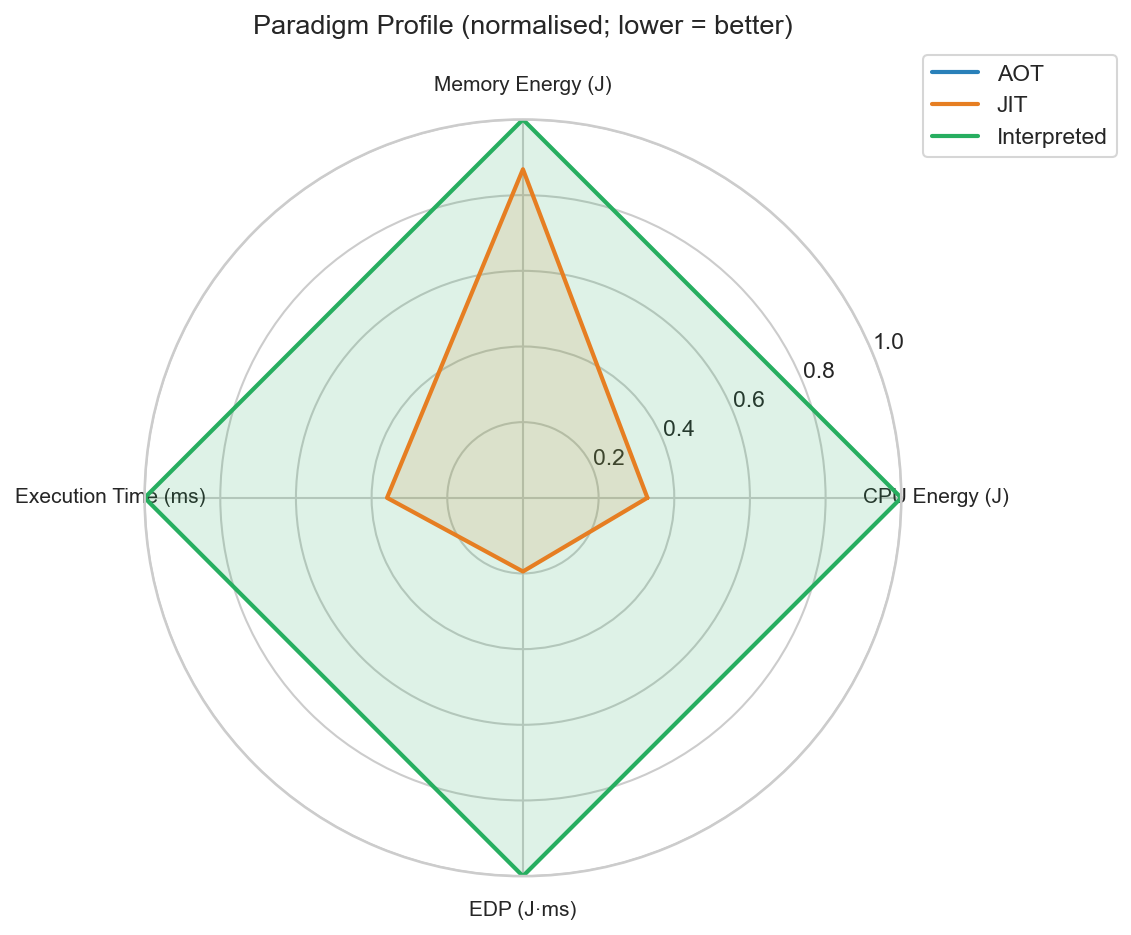

In [6]:
paradigm_agg = df_mean.groupby('paradigm').agg(
    cpu  = (COL_CPU_ENERGY, 'mean'),
    mem  = (COL_MEM_ENERGY, 'mean'),
    time = (COL_TIME, 'mean'),
    edp  = ('EDP', 'mean'),
)

norm = (paradigm_agg - paradigm_agg.min()) / (paradigm_agg.max() - paradigm_agg.min())

categories = ['CPU Energy (J)', 'Memory Energy (J)', 'Execution Time (ms)', 'EDP (J·ms)']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})
for paradigm in PARADIGM_ORDER:
    values = norm.loc[paradigm].tolist()
    values += values[:1]
    ax.plot(angles, values, color=PARADIGM_COLORS[paradigm], linewidth=2, label=paradigm)
    ax.fill(angles, values, color=PARADIGM_COLORS[paradigm], alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 1)
ax.set_title('Paradigm Profile (normalised; lower = better)', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'paradigm_radar.png', bbox_inches='tight')
plt.show()

## 4. Normalised Metrics Heatmap

All four metrics normalised to [0, 1] per column. Lower values (greener) are better.
Enables direct visual comparison of language profiles across all metrics in human-readable units.

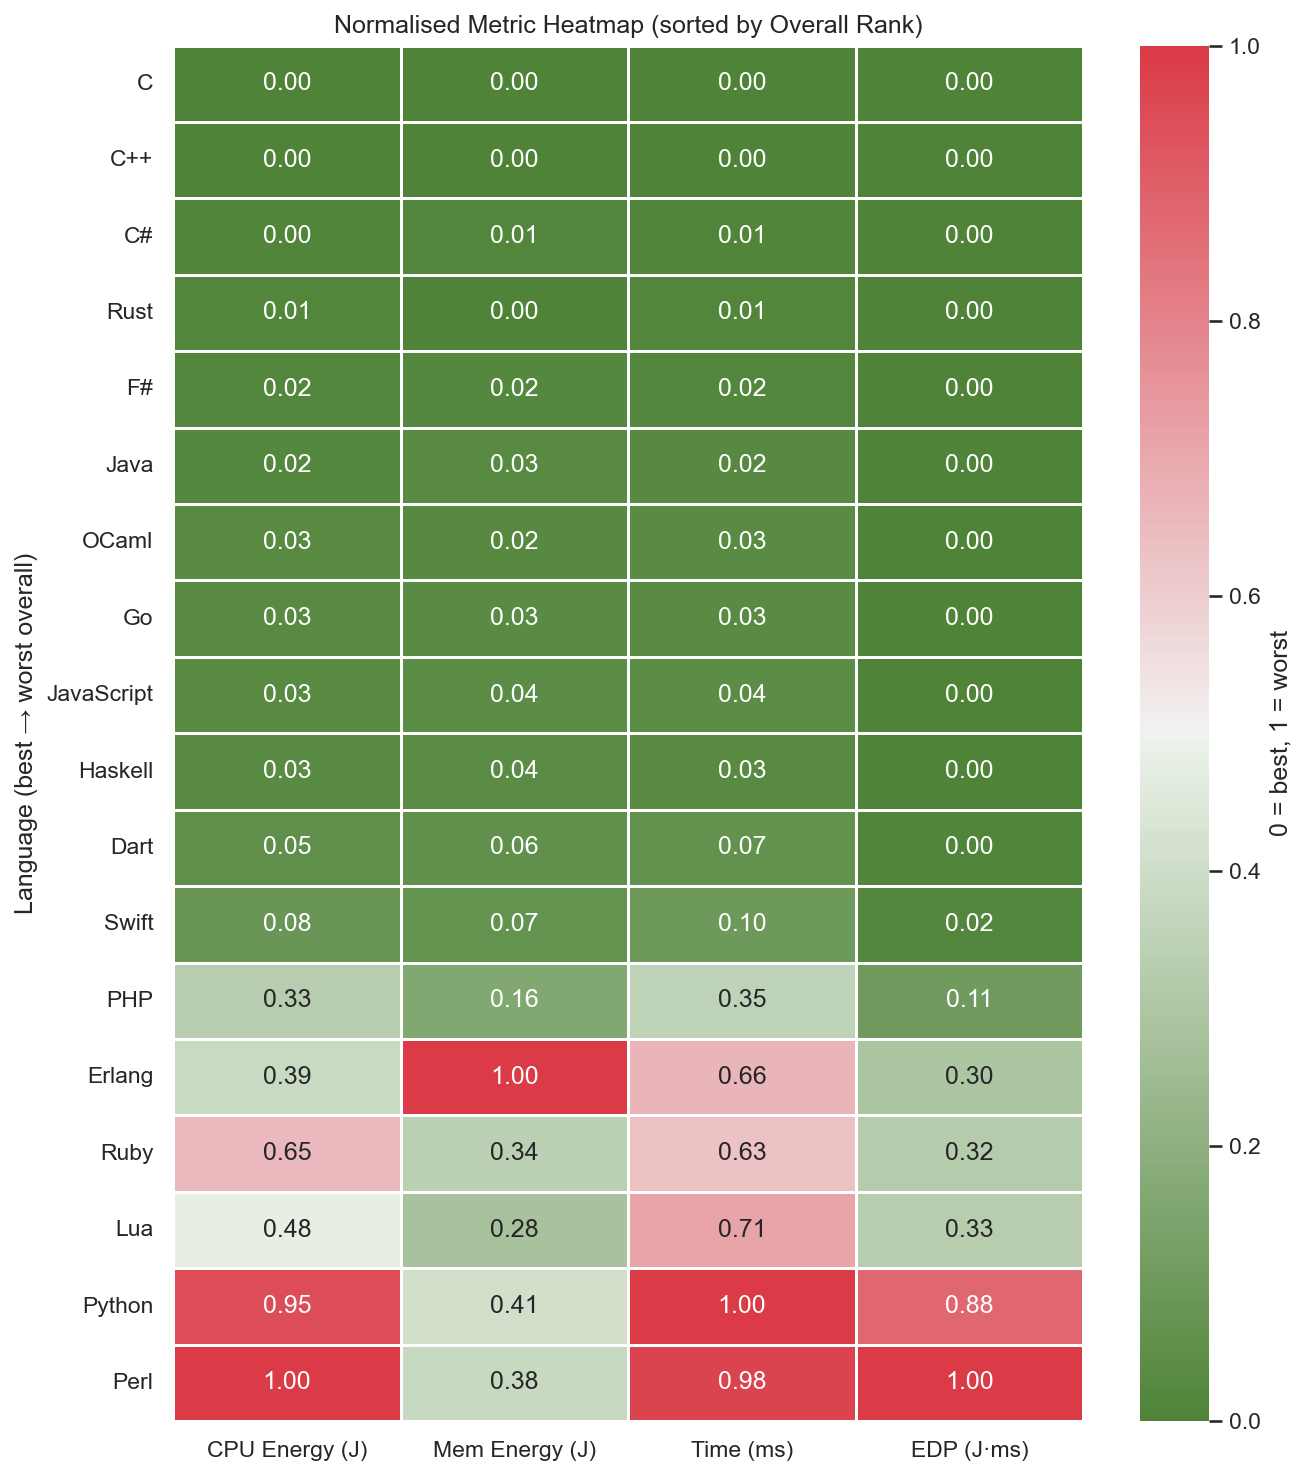

In [7]:
metrics = {
    'CPU Energy (J)': COL_CPU_ENERGY,
    'Mem Energy (J)': COL_MEM_ENERGY,
    'Time (ms)':       COL_TIME,
    'EDP (J·ms)':      'EDP',
}
norm_df = pd.DataFrame(index=ranking.index)
for label, col in metrics.items():
    vals = df_mean.groupby('language')[col].mean()
    norm_df[label] = (vals - vals.min()) / (vals.max() - vals.min())

norm_df = norm_df.loc[ranking.index]  # order by overall rank

fig, ax = plt.subplots(figsize=(9, 10))
sns.heatmap(norm_df, annot=True, fmt='.2f',
            cmap=sns.diverging_palette(120, 10, as_cmap=True),
            center=0.5, vmin=0, vmax=1, ax=ax,
            linewidths=0.5, cbar_kws={'label': '0 = best, 1 = worst'})
ax.set_title('Normalised Metric Heatmap (sorted by Overall Rank)', fontsize=12)
ax.set_ylabel('Language (best → worst overall)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'normalised_heatmap.png', bbox_inches='tight')
plt.show()

## 5. Top 3 / Bottom 3 per Metric

Quick-reference tables for the most and least efficient languages on each metric.
All values in human-readable units (J, ms, J·ms).

In [8]:
metric_cols = {
    'CPU Energy (J)':    COL_CPU_ENERGY,
    'Memory Energy (J)': COL_MEM_ENERGY,
    'Execution Time (ms)':COL_TIME,
    'EDP (J·ms)':         'EDP',
}
units = {'CPU Energy (J)': 'J', 'Memory Energy (J)': 'J',
         'Execution Time (ms)': 'ms', 'EDP (J·ms)': 'J·ms'}

for label, col in metric_cols.items():
    mean_series = df_mean.groupby('language')[col].mean().sort_values()
    top3 = mean_series.head(3)
    bot3 = mean_series.tail(3)
    unit = units[label]
    print(f"\n{'─'*55}")
    print(f"  {label}")
    print(f"  Top 3 (most efficient):")
    for lang, val in top3.items():
        print(f"    • {lang:12s} ({PARADIGM[lang]:12s})  {val:>10.3f} {unit}")
    print(f"  Bottom 3 (least efficient):")
    for lang, val in bot3.items():
        print(f"    • {lang:12s} ({PARADIGM[lang]:12s})  {val:>10.3f} {unit}")


───────────────────────────────────────────────────────
  CPU Energy (J)
  Top 3 (most efficient):
    • C++          (AOT         )      48.005 J
    • C            (AOT         )      54.081 J
    • C#           (AOT         )      66.301 J
  Bottom 3 (least efficient):
    • Ruby         (JIT         )    2519.925 J
    • Python       (Interpreted )    3636.667 J
    • Perl         (Interpreted )    3834.699 J

───────────────────────────────────────────────────────
  Memory Energy (J)
  Top 3 (most efficient):
    • C            (AOT         )       1.089 J
    • C++          (AOT         )       1.264 J
    • Rust         (AOT         )       1.381 J
  Bottom 3 (least efficient):
    • Perl         (Interpreted )      41.236 J
    • Python       (Interpreted )      43.794 J
    • Erlang       (JIT         )     105.971 J

───────────────────────────────────────────────────────
  Execution Time (ms)
  Top 3 (most efficient):
    • C++          (AOT         )    2019.471 ms
    • C

## 6. Key Findings

A bullet-point summary of the main findings in human-readable units (J, ms, J·ms),
suitable for direct citation in the thesis.

In [9]:
cpu_rank_ser  = df_mean.groupby('language')[COL_CPU_ENERGY].mean().sort_values()
time_rank_ser = df_mean.groupby('language')[COL_TIME].mean().sort_values()
edp_rank_ser  = df_mean.groupby('language')['EDP'].mean().sort_values()

aot_cpu  = df_mean[df_mean['paradigm']=='AOT'][COL_CPU_ENERGY].mean()
jit_cpu  = df_mean[df_mean['paradigm']=='JIT'][COL_CPU_ENERGY].mean()
int_cpu  = df_mean[df_mean['paradigm']=='Interpreted'][COL_CPU_ENERGY].mean()
aot_time = df_mean[df_mean['paradigm']=='AOT'][COL_TIME].mean()
jit_time = df_mean[df_mean['paradigm']=='JIT'][COL_TIME].mean()
int_time = df_mean[df_mean['paradigm']=='Interpreted'][COL_TIME].mean()

print("""
KEY FINDINGS — Benchmark Energy & Time Analysis (18 languages, 8 CLBG benchmarks)
═════════════════════════════════════════════════════════════════════════════════""")

print(f"""
CPU ENERGY (unit: J)
  • Most efficient:   {', '.join(cpu_rank_ser.head(3).index)}
  • Least efficient:  {', '.join(cpu_rank_ser.tail(3).index)}
  • AOT mean:         {aot_cpu:.2f} J
  • JIT mean:         {jit_cpu:.2f} J  ({jit_cpu/aot_cpu:.1f}× AOT)
  • Interpreted mean: {int_cpu:.2f} J  ({int_cpu/aot_cpu:.1f}× AOT)

EXECUTION TIME (unit: ms)
  • Fastest:          {', '.join(time_rank_ser.head(3).index)}
  • Slowest:          {', '.join(time_rank_ser.tail(3).index)}
  • AOT mean:         {aot_time:.2f} ms
  • JIT mean:         {jit_time:.2f} ms  ({jit_time/aot_time:.1f}× AOT)
  • Interpreted mean: {int_time:.2f} ms  ({int_time/aot_time:.1f}× AOT)

ENERGY-DELAY PRODUCT (unit: J·ms)
  • Best EDP:         {', '.join(edp_rank_ser.head(3).index)}
  • Worst EDP:        {', '.join(edp_rank_ser.tail(3).index)}
  • Best mean EDP:    {edp_rank_ser.iloc[0]:.2f} J·ms  ({edp_rank_ser.index[0]})
  • Worst mean EDP:   {edp_rank_ser.iloc[-1]:.2f} J·ms ({edp_rank_ser.index[-1]})

Note: All values are two-step means (per-cell mean → mean across 8 CLBG benchmarks,
equal benchmark weight). Use non-parametric tests (notebooks 02–03) for paradigm distributions.
""")


KEY FINDINGS — Benchmark Energy & Time Analysis (18 languages, 8 CLBG benchmarks)
═════════════════════════════════════════════════════════════════════════════════

CPU ENERGY (unit: J)
  • Most efficient:   C++, C, C#
  • Least efficient:  Ruby, Python, Perl
  • AOT mean:         146.28 J
  • JIT mean:         1121.90 J  (7.7× AOT)
  • Interpreted mean: 3111.85 J  (21.3× AOT)

EXECUTION TIME (unit: ms)
  • Fastest:          C++, C, C#
  • Slowest:          Lua, Perl, Python
  • AOT mean:         5810.94 ms
  • JIT mean:         45253.09 ms  (7.8× AOT)
  • Interpreted mean: 115605.76 ms  (19.9× AOT)

ENERGY-DELAY PRODUCT (unit: J·ms)
  • Best EDP:         C, C++, C#
  • Worst EDP:        Lua, Python, Perl
  • Best mean EDP:    159817.84 J·ms  (C)
  • Worst mean EDP:   972394818.50 J·ms (Perl)

Note: All values are two-step means (per-cell mean → mean across 8 CLBG benchmarks,
equal benchmark weight). Use non-parametric tests (notebooks 02–03) for paradigm distributions.

